In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

In [2]:
df = pd.read_csv("../data/processed/healthcare_processed.csv")
raw_df = pd.read_csv("../data/raw/HealthCare.csv")

print("Processed shape:", df.shape)
print("Raw shape:", raw_df.shape)

Processed shape: (110527, 18)
Raw shape: (110527, 14)


In [3]:
#Create X, y and patient groups
X = df.drop(columns=["No_show"])
y = df["No_show"]

groups = raw_df["PatientId"]

print("X:", X.shape)
print("y:", y.shape)
print("Groups:", groups.shape)

X: (110527, 17)
y: (110527,)
Groups: (110527,)


In [4]:
# Patient-level train/test split

In [5]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Training:", X_train.shape)
print("Test:", X_test.shape)

Training: (88491, 17)
Test: (22036, 17)


In [6]:
print(
    "Patient overlap:",
    len(
        set(groups_train).intersection(
            set(groups_test)
        )
    )
)

Patient overlap: 0


In [7]:
# Create validation split

In [8]:
gss_valid = GroupShuffleSplit(
    n_splits=1,
    test_size=0.125,
    random_state=42
)

train_idx_2, valid_idx = next(
    gss_valid.split(
        X_train,
        y_train,
        groups=groups_train
    )
)

X_train_final = X_train.iloc[train_idx_2].copy()
X_valid = X_train.iloc[valid_idx].copy()

y_train_final = y_train.iloc[train_idx_2].copy()
y_valid = y_train.iloc[valid_idx].copy()

groups_train_final = groups_train.iloc[train_idx_2]
groups_valid = groups_train.iloc[valid_idx]

print("Training:", X_train_final.shape)
print("Validation:", X_valid.shape)
print("Test:", X_test.shape)

Training: (77353, 17)
Validation: (11138, 17)
Test: (22036, 17)


In [9]:
print(
    "Train/Validation patient overlap:",
    len(
        set(groups_train_final)
        .intersection(set(groups_valid))
    )
)

Train/Validation patient overlap: 0


In [10]:
# Define features

In [11]:
numeric_features = [
    "Age",
    "Scholarship",
    "Hipertension",
    "Diabetes",
    "Alcoholism",
    "Handcap",
    "SMS_received",
    "WaitingDays",
    "ScheduledHour",
    "AppointmentMonth"
]

categorical_features = [
    "Gender",
    "Neighbourhood",
    "ScheduledDayOfWeek",
    "AppointmentDayOfWeek",
    "AgeGroup",
    "WaitingGroup",
    "ScheduledTimeGroup"
]

In [12]:
# Preprocessing

In [13]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [14]:
# Create the Random Forest

In [15]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        max_features="sqrt",
        min_samples_leaf=1,
        min_samples_split=2,
        random_state=42,
        n_jobs=-1
    ))
])

In [16]:
# Train

In [17]:
rf_pipeline.fit(
    X_train_final,
    y_train_final
)

print("Model training completed.")

Model training completed.


In [18]:
valid_prob = rf_pipeline.predict_proba(
    X_valid
)[:, 1]

print("Validation probabilities generated.")
print(valid_prob[:10])

Validation probabilities generated.
[0.03624407 0.30522942 0.03466825 0.03553051 0.04897738 0.01986264
 0.43509743 0.02757995 0.01855002 0.01891336]


In [19]:
#Test thresholds

In [20]:
thresholds = np.arange(
    0.10,
    0.51,
    0.01
)

threshold_results = []

for threshold in thresholds:

    valid_pred = (
        valid_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_valid,
            valid_pred
        ),
        "Precision": precision_score(
            y_valid,
            valid_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_valid,
            valid_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_valid,
            valid_pred,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.510325,0.282849,0.942998,0.435170
1,0.11,0.513827,0.283932,0.939856,0.436114
2,0.12,0.517059,0.284856,0.936266,0.436813
3,0.13,0.522087,0.286463,0.931777,0.438206
4,0.14,0.527474,0.287911,0.924596,0.439092
5,0.15,0.533579,0.289305,0.914273,0.439530
6,0.16,0.542108,0.292065,0.905296,0.441647
7,0.17,0.553331,0.295519,0.890934,0.443823
8,0.18,0.564733,0.298585,0.871634,0.444801
9,0.19,0.577931,0.302697,0.851436,0.446616


In [21]:
#Find the F1-optimal threshold

In [24]:
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

selected_threshold = float(
    best_row["Threshold"]
)

print("Selected Threshold:", selected_threshold)
print("Validation Accuracy:", best_row["Accuracy"])
print("Validation Precision:", best_row["Precision"])
print("Validation Recall:", best_row["Recall"])
print("Validation F1:", best_row["F1"])

Selected Threshold: 0.23999999999999994
Validation Accuracy: 0.6551445501885437
Validation Precision: 0.33074501573976917
Validation Recall: 0.7073608617594255
Validation F1: 0.45073645073645074


In [23]:
#Plot threshold vs metrics

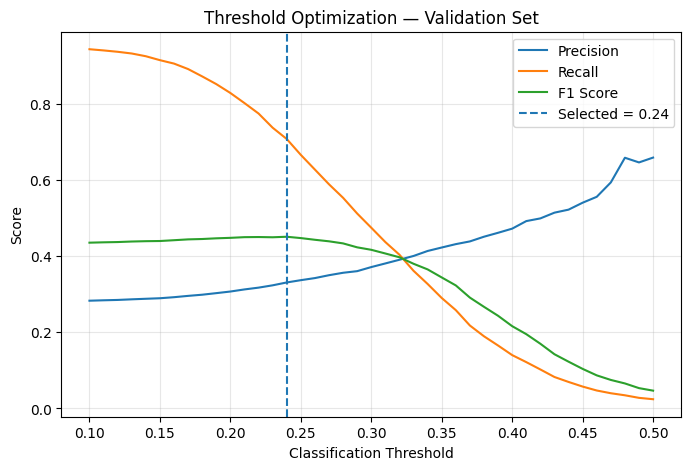

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1 Score"
)

plt.axvline(
    selected_threshold,
    linestyle="--",
    label=f"Selected = {selected_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization — Validation Set")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [26]:
# Evaluate selected threshold on test data

In [27]:
test_prob = rf_pipeline.predict_proba(
    X_test
)[:, 1]

test_pred = (
    test_prob >= selected_threshold
).astype(int)

In [28]:
test_accuracy = accuracy_score(
    y_test,
    test_pred
)

test_precision = precision_score(
    y_test,
    test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_pred,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    y_test,
    test_prob
)

test_pr_auc = average_precision_score(
    y_test,
    test_prob
)

In [29]:
print("FINAL THRESHOLD EVALUATION")
print("=" * 50)

print(f"Selected Threshold : {selected_threshold:.2f}")
print(f"Accuracy            : {test_accuracy:.4f}")
print(f"Precision           : {test_precision:.4f}")
print(f"Recall              : {test_recall:.4f}")
print(f"F1 Score            : {test_f1:.4f}")
print(f"ROC-AUC             : {test_roc_auc:.4f}")
print(f"PR-AUC              : {test_pr_auc:.4f}")

FINAL THRESHOLD EVALUATION
Selected Threshold : 0.24
Accuracy            : 0.6507
Precision           : 0.3284
Recall              : 0.7036
F1 Score            : 0.4478
ROC-AUC             : 0.7360
PR-AUC              : 0.3673


In [30]:
# Confusion matrix

In [31]:
cm = confusion_matrix(
    y_test,
    test_pred
)

print(cm)

[[11217  6383]
 [ 1315  3121]]


In [32]:
# Save the production threshold

In [33]:
import json

threshold_data = {
    "threshold": selected_threshold,
    "selection_method": "Maximum validation F1",
    "evaluation_method": "Patient-level split",
    "prediction_timing": "Shortly before appointment after SMS status is available",
    "model": "Random Forest"
}

with open(
    "../models/threshold.json",
    "w"
) as f:
    json.dump(
        threshold_data,
        f,
        indent=4
    )

print("Threshold saved successfully.")

Threshold saved successfully.


In [34]:
with open("../models/threshold.json", "r") as f:
    print(json.load(f))

{'threshold': 0.23999999999999994, 'selection_method': 'Maximum validation F1', 'evaluation_method': 'Patient-level split', 'prediction_timing': 'Shortly before appointment after SMS status is available', 'model': 'Random Forest'}


In [35]:
final_metrics = pd.DataFrame({
    "Metric": [
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Score": [
        selected_threshold,
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc,
        test_pr_auc
    ]
})

final_metrics.to_csv(
    "../models/final_evaluation_metrics.csv",
    index=False
)

print("Final evaluation metrics saved successfully.")

Final evaluation metrics saved successfully.
